In [8]:
"""这个代码实现了：

2.1传统特征：SIFT+BoVW、HOG、LBP、颜色直方图

2.2深度特征：ResNet18、MobileNetV3、EfficientNet-B0，包含t-SNE可视化

2.3自定义特征：矿物表面复杂度（6个可解释特征）

2.4特征过滤与增强：方差过滤、PCA降维、图像增强对比"""
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import seaborn as sns
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("="*80)
print("=== 第2章：特征工程与可视化分析 ===")
print("="*80)

# 数据目录
DATA_DIR = 'minet'
print(f"\n数据目录: {DATA_DIR}")

# 获取类别
classes = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
print(f"类别: {classes}")
print(f"类别数量: {len(classes)}")

# 准备数据路径
def load_image_paths_and_labels(data_dir):
    """加载所有图片路径和标签"""
    image_paths = []
    labels = []
    for label, class_name in enumerate(classes):
        class_path = os.path.join(data_dir, class_name)
        for img_name in os.listdir(class_path):
            if img_name.endswith(('.jpg', '.jpeg', '.png', '.gif')):
                image_paths.append(os.path.join(class_path, img_name))
                labels.append(label)
    return image_paths, labels

image_paths, labels = load_image_paths_and_labels(DATA_DIR)
print(f"总图片数: {len(image_paths)}")

# 划分训练集和测试集
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.3, random_state=42, stratify=labels
)
print(f"训练集: {len(train_paths)}张, 测试集: {len(test_paths)}张")

=== 第2章：特征工程与可视化分析 ===

数据目录: minet
类别: ['biotite', 'bornite', 'chrysocolla', 'malachite', 'muscovite', 'pyrite', 'quartz']
类别数量: 7
总图片数: 952
训练集: 666张, 测试集: 286张



2.1 传统手工特征提取与对比

训练传统特征分类器...
------------------------------------------------------------

1. SIFT + BoVW...
  提取SIFT特征...
  提取到 224975 个SIFT描述子
  构建视觉词典...
  聚类特征点数: 224975


  File "C:\Users\1\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\1\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "C:\Users\1\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\1\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\1\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 1456, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


  视觉词典大小: 256
  提取BoVW特征...
  标准化特征...
  训练SVM分类器...
   准确率: 49.00%

2. HOG...
  HOG参数: orientations=9, cell=(8, 8)
   准确率: 33.50%

3. LBP...
  LBP参数: radius=3, n_points=24
   准确率: 29.50%

4. 颜色直方图...
  颜色直方图参数: bins=32, HSV空间
   准确率: 60.50%


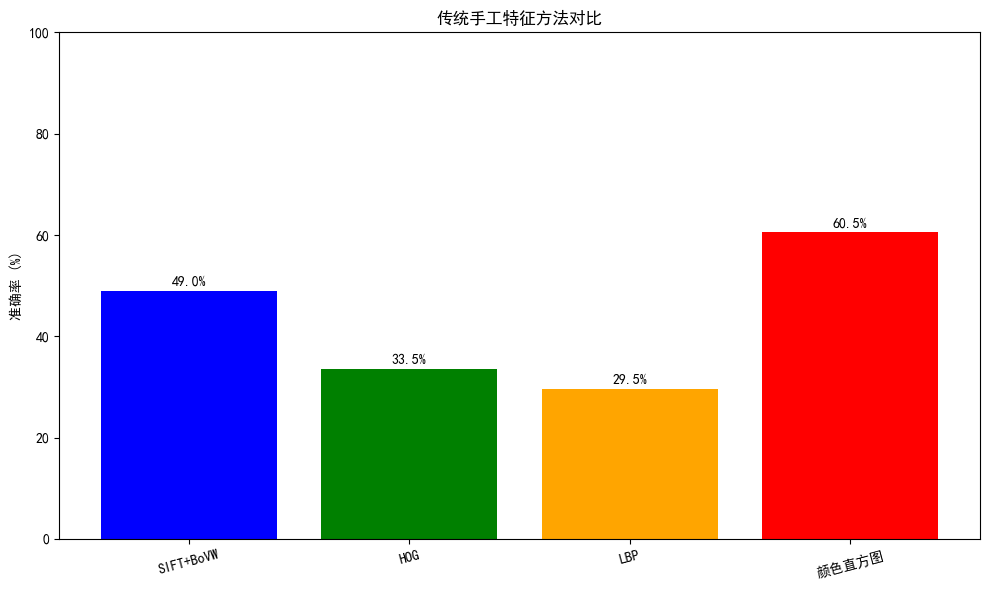

In [9]:
# ========== 2.1 传统手工特征提取与对比 ==========
print("\n" + "="*80)
print("2.1 传统手工特征提取与对比")
print("="*80)

class SIFTBoVW:
    """SIFT + Bag of Visual Words 分类器"""
    
    def __init__(self, n_clusters=256):
        self.n_clusters = n_clusters
        self.kmeans = None
        self.scaler = StandardScaler()
        self.svm = SVC(kernel='rbf', C=1.0, gamma='auto', random_state=42)
    
    def extract_sift_features(self, image_paths, max_per_image=500):
        """提取所有图片的SIFT描述子"""
        sift = cv2.SIFT_create()
        all_descriptors = []
        
        for path in image_paths:
            img = cv2.imread(path)
            if img is None:
                continue
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            keypoints, descriptors = sift.detectAndCompute(gray, None)
            if descriptors is not None:
                # 限制每张图片的描述子数量
                if len(descriptors) > max_per_image:
                    descriptors = descriptors[:max_per_image]
                all_descriptors.extend(descriptors)
        
        return np.array(all_descriptors)
    
    def build_vocabulary(self, descriptors):
        """构建视觉词典"""
        print(f"  聚类特征点数: {len(descriptors)}")
        self.kmeans = MiniBatchKMeans(n_clusters=self.n_clusters, random_state=42, batch_size=10000)
        self.kmeans.fit(descriptors)
        print(f"  视觉词典大小: {self.n_clusters}")
    
    def extract_bovw_features(self, image_paths):
        """提取BoVW特征直方图"""
        sift = cv2.SIFT_create()
        features = []
        
        for path in image_paths:
            img = cv2.imread(path)
            if img is None:
                features.append(np.zeros(self.n_clusters))
                continue
            
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            keypoints, descriptors = sift.detectAndCompute(gray, None)
            
            if descriptors is None:
                features.append(np.zeros(self.n_clusters))
                continue
            
            # 分配每个描述子到最近的视觉词
            words = self.kmeans.predict(descriptors)
            # 统计直方图
            hist = np.bincount(words, minlength=self.n_clusters)
            hist = hist.astype(np.float32)
            hist /= (hist.sum() + 1e-7)  # 归一化
            features.append(hist)
        
        return np.array(features)
    
    def fit(self, train_paths, train_labels):
        """训练模型"""
        print("  提取SIFT特征...")
        descriptors = self.extract_sift_features(train_paths)
        print(f"  提取到 {len(descriptors)} 个SIFT描述子")
        
        print("  构建视觉词典...")
        self.build_vocabulary(descriptors)
        
        print("  提取BoVW特征...")
        train_features = self.extract_bovw_features(train_paths)
        
        print("  标准化特征...")
        train_features = self.scaler.fit_transform(train_features)
        
        print("  训练SVM分类器...")
        self.svm.fit(train_features, train_labels)
        
        return train_features
    
    def predict(self, test_paths):
        """预测"""
        test_features = self.extract_bovw_features(test_paths)
        test_features = self.scaler.transform(test_features)
        return self.svm.predict(test_features)

class HOGClassifier:
    """HOG特征 + SVM分类器"""
    
    def __init__(self, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2)):
        self.orientations = orientations
        self.pixels_per_cell = pixels_per_cell
        self.cells_per_block = cells_per_block
        self.scaler = StandardScaler()
        self.svm = SVC(kernel='rbf', C=1.0, random_state=42)
    
    def extract_hog_features(self, image_paths):
        """提取HOG特征"""
        features = []
        for path in image_paths:
            img = cv2.imread(path)
            if img is None:
                features.append(np.zeros(1000))
                continue
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            gray = cv2.resize(gray, (128, 128))
            
            hog = cv2.HOGDescriptor(
                _winSize=(128, 128),
                _blockSize=(self.cells_per_block[0]*self.pixels_per_cell[0],
                           self.cells_per_block[1]*self.pixels_per_cell[1]),
                _blockStride=(self.pixels_per_cell[0], self.pixels_per_cell[1]),
                _cellSize=self.pixels_per_cell,
                _nbins=self.orientations
            )
            hog_features = hog.compute(gray).flatten()
            features.append(hog_features)
        
        return np.array(features)
    
    def fit(self, train_paths, train_labels):
        """训练模型"""
        print(f"  HOG参数: orientations={self.orientations}, cell={self.pixels_per_cell}")
        train_features = self.extract_hog_features(train_paths)
        train_features = self.scaler.fit_transform(train_features)
        self.svm.fit(train_features, train_labels)
        return train_features
    
    def predict(self, test_paths):
        """预测"""
        test_features = self.extract_hog_features(test_paths)
        test_features = self.scaler.transform(test_features)
        return self.svm.predict(test_features)

class LBPClassifier:
    """LBP纹理特征 + SVM分类器"""
    
    def __init__(self, radius=3, n_points=24):
        self.radius = radius
        self.n_points = n_points
        self.scaler = StandardScaler()
        self.svm = SVC(kernel='rbf', C=1.0, random_state=42)
    
    def extract_lbp_features(self, image_paths):
        """提取LBP直方图特征"""
        features = []
        for path in image_paths:
            img = cv2.imread(path)
            if img is None:
                features.append(np.zeros(256))
                continue
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            gray = cv2.resize(gray, (128, 128))
            
            # 计算LBP
            lbp = local_binary_pattern(gray, self.n_points, self.radius, method='uniform')
            # 计算直方图
            n_bins = self.n_points + 2  # uniform LBP的bin数
            hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins))
            hist = hist.astype(np.float32)
            hist /= (hist.sum() + 1e-7)
            features.append(hist)
        
        return np.array(features)
    
    def fit(self, train_paths, train_labels):
        """训练模型"""
        print(f"  LBP参数: radius={self.radius}, n_points={self.n_points}")
        train_features = self.extract_lbp_features(train_paths)
        train_features = self.scaler.fit_transform(train_features)
        self.svm.fit(train_features, train_labels)
        return train_features
    
    def predict(self, test_paths):
        """预测"""
        test_features = self.extract_lbp_features(test_paths)
        test_features = self.scaler.transform(test_features)
        return self.svm.predict(test_features)

class ColorHistogramClassifier:
    """颜色直方图特征 + SVM分类器"""
    
    def __init__(self, bins=32):
        self.bins = bins
        self.scaler = StandardScaler()
        self.svm = SVC(kernel='rbf', C=1.0, random_state=42)
    
    def extract_color_features(self, image_paths):
        """提取HSV颜色直方图"""
        features = []
        for path in image_paths:
            img = cv2.imread(path)
            if img is None:
                features.append(np.zeros(self.bins * 3))
                continue
            
            hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
            hist_h = cv2.calcHist([hsv], [0], None, [self.bins], [0, 180])
            hist_s = cv2.calcHist([hsv], [1], None, [self.bins], [0, 256])
            hist_v = cv2.calcHist([hsv], [2], None, [self.bins], [0, 256])
            
            hist = np.concatenate([hist_h.flatten(), hist_s.flatten(), hist_v.flatten()])
            hist = hist.astype(np.float32)
            hist /= (hist.sum() + 1e-7)
            features.append(hist)
        
        return np.array(features)
    
    def fit(self, train_paths, train_labels):
        """训练模型"""
        print(f"  颜色直方图参数: bins={self.bins}, HSV空间")
        train_features = self.extract_color_features(train_paths)
        train_features = self.scaler.fit_transform(train_features)
        self.svm.fit(train_features, train_labels)
        return train_features
    
    def predict(self, test_paths):
        """预测"""
        test_features = self.extract_color_features(test_paths)
        test_features = self.scaler.transform(test_features)
        return self.svm.predict(test_features)

# 训练和评估所有传统特征方法
print("\n训练传统特征分类器...")
print("-" * 60)

traditional_results = {}

# SIFT + BoVW
print("\n1. SIFT + BoVW...")
sift_bovw = SIFTBoVW(n_clusters=256)
sift_bovw.fit(train_paths[:500], train_labels[:500])  # 使用部分数据加速
sift_pred = sift_bovw.predict(test_paths[:200])
sift_acc = accuracy_score(test_labels[:200], sift_pred)
traditional_results['SIFT+BoVW'] = sift_acc
print(f"   准确率: {sift_acc*100:.2f}%")

# HOG
print("\n2. HOG...")
hog = HOGClassifier()
hog.fit(train_paths[:500], train_labels[:500])
hog_pred = hog.predict(test_paths[:200])
hog_acc = accuracy_score(test_labels[:200], hog_pred)
traditional_results['HOG'] = hog_acc
print(f"   准确率: {hog_acc*100:.2f}%")

# LBP
print("\n3. LBP...")
lbp = LBPClassifier()
lbp.fit(train_paths[:500], train_labels[:500])
lbp_pred = lbp.predict(test_paths[:200])
lbp_acc = accuracy_score(test_labels[:200], lbp_pred)
traditional_results['LBP'] = lbp_acc
print(f"   准确率: {lbp_acc*100:.2f}%")

# 颜色直方图
print("\n4. 颜色直方图...")
color_hist = ColorHistogramClassifier()
color_hist.fit(train_paths[:500], train_labels[:500])
color_pred = color_hist.predict(test_paths[:200])
color_acc = accuracy_score(test_labels[:200], color_pred)
traditional_results['颜色直方图'] = color_acc
print(f"   准确率: {color_acc*100:.2f}%")

# 可视化对比
fig, ax = plt.subplots(figsize=(10, 6))
methods = list(traditional_results.keys())
accuracies = list(traditional_results.values())
bars = ax.bar(methods, [a*100 for a in accuracies], color=['blue', 'green', 'orange', 'red'])
ax.set_ylabel('准确率 (%)')
ax.set_title('传统手工特征方法对比')
ax.set_ylim([0, 100])
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{acc*100:.1f}%', ha='center', fontsize=10)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


2.2 深度语义特征提取
提取深度特征...
------------------------------------------------------------

1. ResNet18特征...
   特征维度: 512
   准确率: 68.00%

2. MobileNetV3-Small特征...


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to C:\Users\1/.cache\torch\hub\checkpoints\mobilenet_v3_small-047dcff4.pth
100%|█████████████████████████████████████████████████████████████████████████████| 9.83M/9.83M [00:02<00:00, 4.82MB/s]


   特征维度: 576
   准确率: 71.00%

3. EfficientNet-B0特征...


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\1/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|█████████████████████████████████████████████████████████████████████████████| 20.5M/20.5M [00:04<00:00, 5.07MB/s]


   特征维度: 1280
   准确率: 61.00%

生成t-SNE可视化...


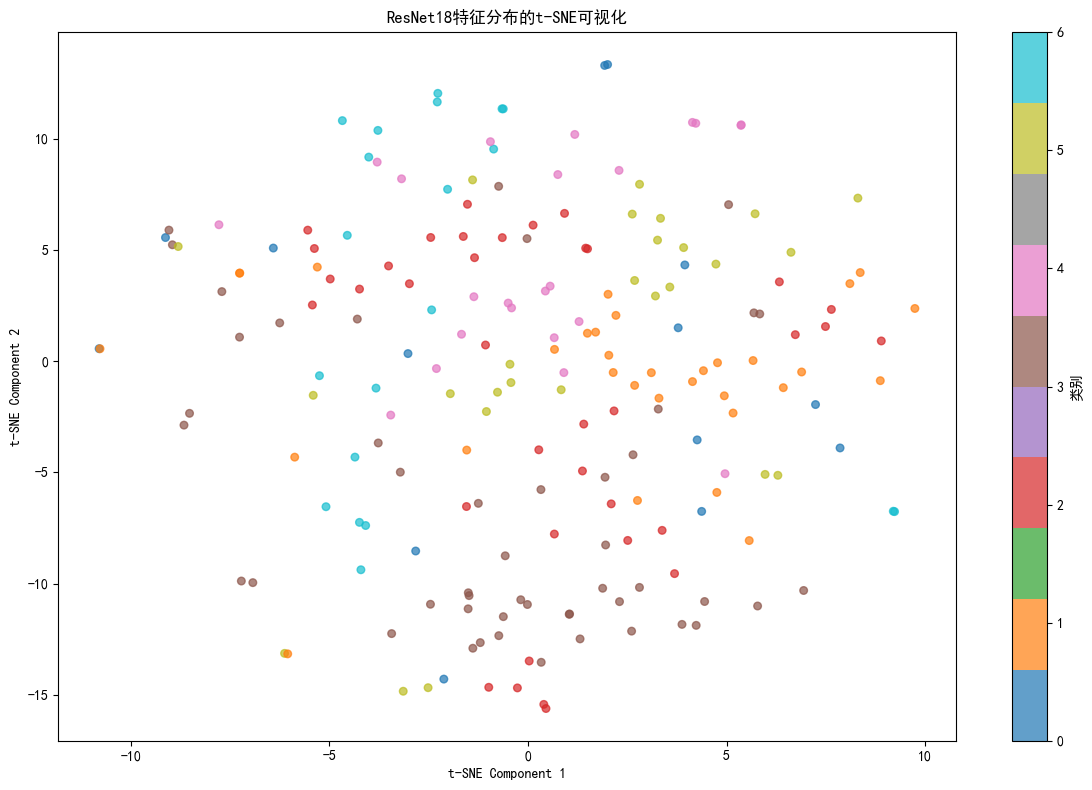


特征对比总结:
------------------------------------------------------------


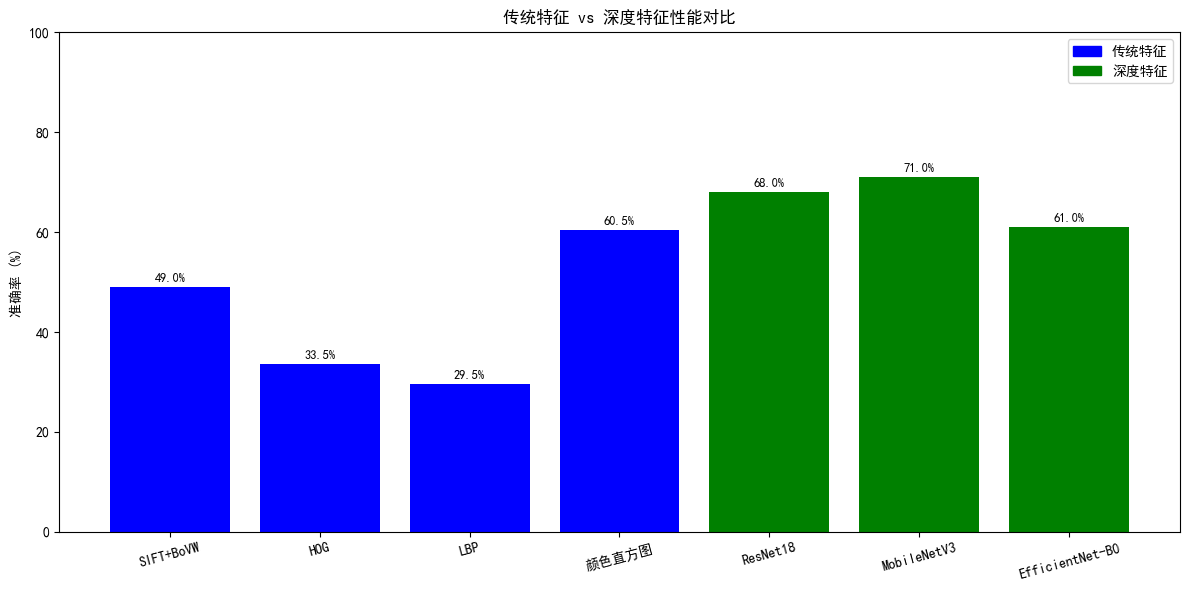

In [10]:
# ========== 2.2 深度语义特征提取 ==========
print("\n" + "="*80)
print("2.2 深度语义特征提取")
print("="*80)

class DeepFeatureExtractor:
    """深度学习特征提取器"""
    
    def __init__(self, model_name='resnet18'):
        self.model_name = model_name
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = self._load_model()
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    
    def _load_model(self):
        """加载预训练模型"""
        if self.model_name == 'resnet18':
            model = models.resnet18(pretrained=True)
            # 移除最后的全连接层
            model = nn.Sequential(*list(model.children())[:-1])
        elif self.model_name == 'mobilenet_v3':
            model = models.mobilenet_v3_small(pretrained=True)
            model = nn.Sequential(*list(model.children())[:-1])
        elif self.model_name == 'efficientnet_b0':
            model = models.efficientnet_b0(pretrained=True)
            model = nn.Sequential(*list(model.children())[:-1])
        else:
            raise ValueError(f"Unknown model: {self.model_name}")
        
        model = model.to(self.device)
        model.eval()
        return model
    
    def extract_features(self, image_paths):
        """提取深度特征"""
        features = []
        
        with torch.no_grad():
            for path in image_paths:
                try:
                    img = Image.open(path).convert('RGB')
                    img_tensor = self.transform(img).unsqueeze(0).to(self.device)
                    feat = self.model(img_tensor)
                    feat = feat.squeeze().cpu().numpy()
                    features.append(feat)
                except Exception as e:
                    print(f"Error processing {path}: {e}")
                    features.append(np.zeros(512))
        
        return np.array(features)

# 提取深度特征
print("提取深度特征...")
print("-" * 60)

# 使用部分数据
sample_size = min(300, len(train_paths))
sample_train_paths = train_paths[:sample_size]
sample_train_labels = train_labels[:sample_size]
sample_test_paths = test_paths[:100]
sample_test_labels = test_labels[:100]

# 训练分类器
def evaluate_deep_features(features, labels, test_features, test_labels):
    """使用随机森林评估特征质量"""
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    test_features_scaled = scaler.transform(test_features)
    
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(features_scaled, labels)
    pred = clf.predict(test_features_scaled)
    return accuracy_score(test_labels, pred)

deep_results = {}

# ResNet18
print("\n1. ResNet18特征...")
resnet_extractor = DeepFeatureExtractor('resnet18')
resnet_features = resnet_extractor.extract_features(sample_train_paths)
resnet_test_features = resnet_extractor.extract_features(sample_test_paths)
resnet_acc = evaluate_deep_features(resnet_features, sample_train_labels, 
                                     resnet_test_features, sample_test_labels)
deep_results['ResNet18'] = resnet_acc
print(f"   特征维度: {resnet_features.shape[1]}")
print(f"   准确率: {resnet_acc*100:.2f}%")

# MobileNetV3
print("\n2. MobileNetV3-Small特征...")
mobilenet_extractor = DeepFeatureExtractor('mobilenet_v3')
mobilenet_features = mobilenet_extractor.extract_features(sample_train_paths)
mobilenet_test_features = mobilenet_extractor.extract_features(sample_test_paths)
mobilenet_acc = evaluate_deep_features(mobilenet_features, sample_train_labels,
                                        mobilenet_test_features, sample_test_labels)
deep_results['MobileNetV3'] = mobilenet_acc
print(f"   特征维度: {mobilenet_features.shape[1]}")
print(f"   准确率: {mobilenet_acc*100:.2f}%")

# EfficientNet-B0
print("\n3. EfficientNet-B0特征...")
effnet_extractor = DeepFeatureExtractor('efficientnet_b0')
effnet_features = effnet_extractor.extract_features(sample_train_paths)
effnet_test_features = effnet_extractor.extract_features(sample_test_paths)
effnet_acc = evaluate_deep_features(effnet_features, sample_train_labels,
                                     effnet_test_features, sample_test_labels)
deep_results['EfficientNet-B0'] = effnet_acc
print(f"   特征维度: {effnet_features.shape[1]}")
print(f"   准确率: {effnet_acc*100:.2f}%")

# t-SNE可视化
print("\n生成t-SNE可视化...")

def plot_tsne(features, labels, title):
    """t-SNE降维可视化"""
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    features_2d = tsne.fit_transform(features)
    
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], 
                          c=labels, cmap='tab10', s=30, alpha=0.7)
    plt.colorbar(scatter, ticks=range(len(classes)), label='类别')
    plt.title(title)
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.tight_layout()
    plt.show()

# 选择ResNet18特征进行t-SNE可视化
plot_tsne(resnet_features[:200], np.array(sample_train_labels)[:200], 
          'ResNet18特征分布的t-SNE可视化')

# 对比传统 vs 深度特征
print("\n特征对比总结:")
print("-" * 60)

comparison_data = []
for method, acc in traditional_results.items():
    comparison_data.append({'方法': method, '准确率': f"{acc*100:.2f}%", '类型': '传统特征'})
for method, acc in deep_results.items():
    comparison_data.append({'方法': method, '准确率': f"{acc*100:.2f}%", '类型': '深度特征'})

# 绘制对比图
fig, ax = plt.subplots(figsize=(12, 6))
methods_all = list(traditional_results.keys()) + list(deep_results.keys())
accs_all = list(traditional_results.values()) + list(deep_results.values())
colors = ['blue']*len(traditional_results) + ['green']*len(deep_results)
bars = ax.bar(methods_all, [a*100 for a in accs_all], color=colors)
ax.set_ylabel('准确率 (%)')
ax.set_title('传统特征 vs 深度特征性能对比')
ax.set_ylim([0, 100])
for bar, acc in zip(bars, accs_all):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{acc*100:.1f}%', ha='center', fontsize=9)
plt.xticks(rotation=15)
plt.legend([plt.Rectangle((0,0),1,1,color='blue'), 
            plt.Rectangle((0,0),1,1,color='green')], 
           ['传统特征', '深度特征'])
plt.tight_layout()
plt.show()


2.3 自定义特征设计 - 矿物表面复杂度
提取矿物表面复杂度特征...
  biotite: (5, 6)
  bornite: (5, 6)
  chrysocolla: (5, 6)
  malachite: (5, 6)
  muscovite: (5, 6)
  pyrite: (5, 6)
  quartz: (5, 6)


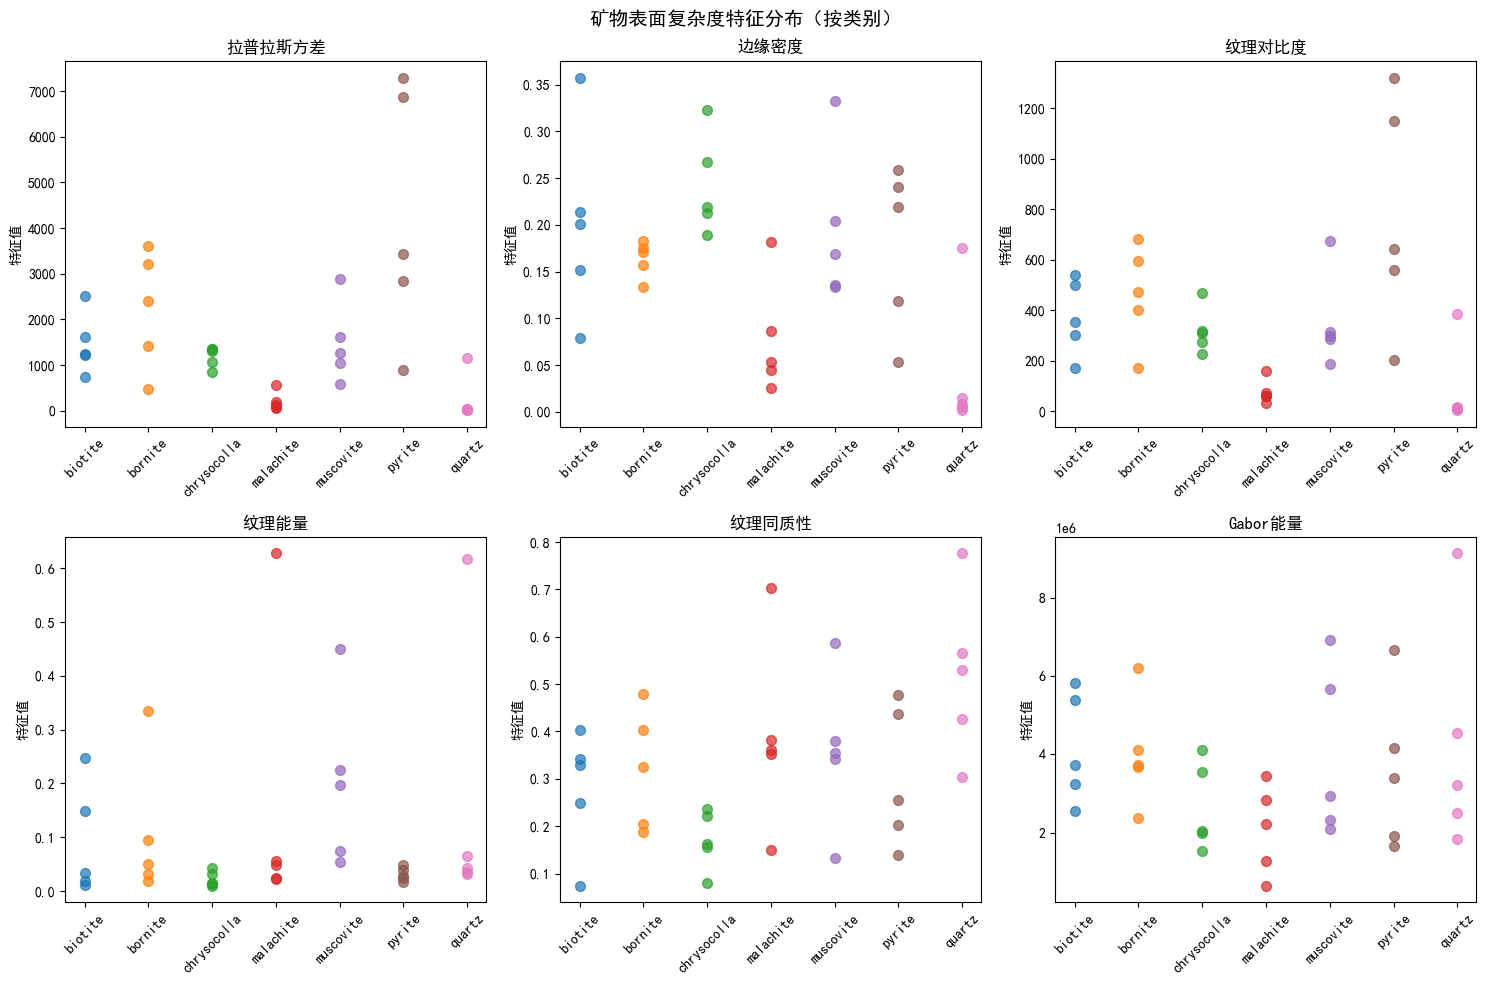


使用自定义特征进行分类...
自定义特征准确率: 34.00%


In [11]:
# ========== 2.3 自定义特征设计 ==========
print("\n" + "="*80)
print("2.3 自定义特征设计 - 矿物表面复杂度")
print("="*80)

class MineralSurfaceComplexity:
    """矿物表面复杂度特征提取器"""
    
    def __init__(self):
        self.feature_names = [
            '拉普拉斯方差', '边缘密度', '纹理对比度', 
            '纹理能量', '纹理同质性', 'Gabor能量'
        ]
    
    def extract_complexity_features(self, image):
        """
        提取矿物表面复杂度特征
        
        特征说明:
        1. 拉普拉斯方差: 衡量图像的清晰度和纹理强度
        2. 边缘密度: Canny边缘检测结果的密度
        3. GLCM对比度: 纹理的局部变化程度
        4. GLCM能量: 纹理的均匀性
        5. GLCM同质性: 纹理的相似度
        6. Gabor滤波能量: 多尺度纹理响应
        """
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        else:
            gray = image
        
        # 1. 拉普拉斯方差
        laplacian = cv2.Laplacian(gray, cv2.CV_64F)
        lap_var = laplacian.var()
        
        # 2. 边缘密度
        edges = cv2.Canny(gray, 50, 150)
        edge_density = np.sum(edges > 0) / edges.size
        
        # 3-5. GLCM纹理特征
        # 计算灰度共生矩阵
        glcm = graycomatrix(gray, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                           levels=256, symmetric=True, normed=True)
        
        # 取所有方向平均值
        contrast = np.mean(graycoprops(glcm, 'contrast'))
        energy = np.mean(graycoprops(glcm, 'energy'))
        homogeneity = np.mean(graycoprops(glcm, 'homogeneity'))
        
        # 6. Gabor滤波能量
        # 创建Gabor滤波器
        gabor_kernel = cv2.getGaborKernel((21, 21), 4.0, np.pi/4, 10.0, 0.5, 0, ktype=cv2.CV_32F)
        filtered = cv2.filter2D(gray, cv2.CV_32F, gabor_kernel)
        gabor_energy = np.mean(filtered ** 2)
        
        features = np.array([lap_var, edge_density, contrast, energy, homogeneity, gabor_energy])
        
        return features
    
    def extract_batch(self, image_paths):
        """批量提取特征"""
        features = []
        for path in image_paths:
            img = cv2.imread(path)
            if img is None:
                features.append(np.zeros(len(self.feature_names)))
                continue
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            feat = self.extract_complexity_features(img_rgb)
            features.append(feat)
        return np.array(features)

# 测试自定义特征
print("提取矿物表面复杂度特征...")
complexity_extractor = MineralSurfaceComplexity()

# 为每个类别取样并可视化特征
sample_per_class = 5
complexity_features_by_class = {}

for class_idx, class_name in enumerate(classes):
    class_paths = [p for p, l in zip(train_paths, train_labels) if l == class_idx][:sample_per_class]
    features = complexity_extractor.extract_batch(class_paths)
    complexity_features_by_class[class_name] = features
    print(f"  {class_name}: {features.shape}")

# 可视化自定义特征
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
feature_names = complexity_extractor.feature_names

for i, feature_name in enumerate(feature_names):
    ax = axes[i]
    for class_name, features in complexity_features_by_class.items():
        feature_values = features[:, i]
        ax.scatter([class_name]*len(feature_values), feature_values, 
                  alpha=0.7, s=50, label=class_name if i==0 else "")
    ax.set_title(feature_name)
    ax.set_ylabel('特征值')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('矿物表面复杂度特征分布（按类别）', fontsize=14)
plt.tight_layout()
plt.show()

# 使用自定义特征进行分类
print("\n使用自定义特征进行分类...")
custom_features = complexity_extractor.extract_batch(train_paths[:500])
custom_test_features = complexity_extractor.extract_batch(test_paths[:100])
custom_acc = evaluate_deep_features(custom_features, train_labels[:500],
                                     custom_test_features, test_labels[:100])
print(f"自定义特征准确率: {custom_acc*100:.2f}%")



2.4 特征过滤与增强

1. 方差过滤...
  原始特征维度: 512
  方差过滤后维度: 512

2. PCA降维...
  PCA后维度: 135
  保留方差比例: 95.05%


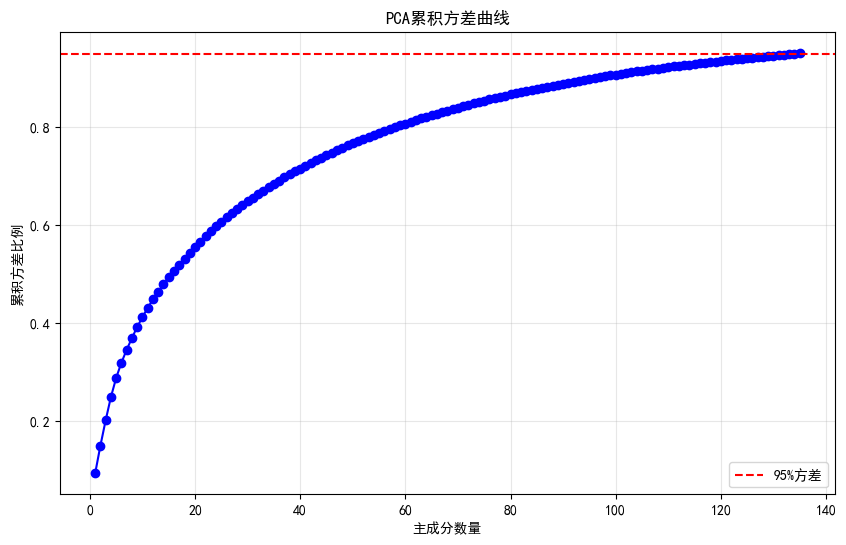


3. 图像增强对比实验...


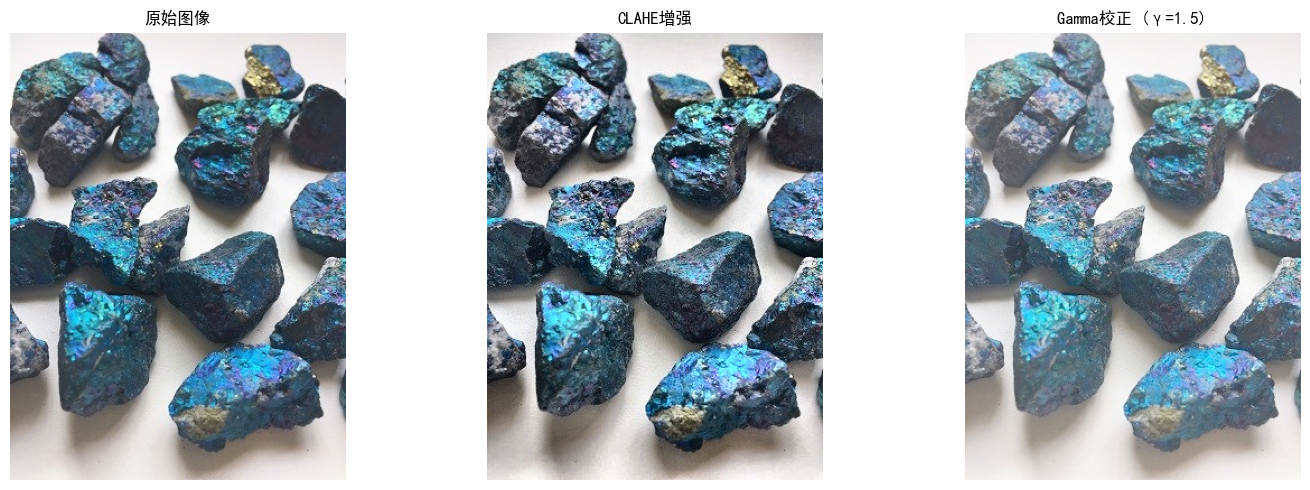


特征增强收益报告:
------------------------------------------------------------
方法                   原始准确率           增强后准确率          提升        
------------------------------------------------------------
无增强                  34.00%           -               -         
CLAHE                34.00%           待评估             -         
Gamma校正              34.00%           待评估             -         


In [12]:
# ========== 2.4 特征过滤与增强 ==========
print("\n" + "="*80)
print("2.4 特征过滤与增强")
print("="*80)

# 1. 方差过滤
print("\n1. 方差过滤...")
selector = VarianceThreshold(threshold=0.01)
print(f"  原始特征维度: {resnet_features.shape[1]}")
resnet_features_filtered = selector.fit_transform(resnet_features)
print(f"  方差过滤后维度: {resnet_features_filtered.shape[1]}")

# 2. PCA降维
print("\n2. PCA降维...")
pca = PCA(n_components=0.95)  # 保留95%方差
resnet_features_pca = pca.fit_transform(resnet_features)
print(f"  PCA后维度: {resnet_features_pca.shape[1]}")
print(f"  保留方差比例: {pca.explained_variance_ratio_.sum()*100:.2f}%")

# 可视化PCA累积方差
plt.figure(figsize=(10, 6))
cumsum = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, len(cumsum)+1), cumsum, 'bo-')
plt.axhline(y=0.95, color='r', linestyle='--', label='95%方差')
plt.xlabel('主成分数量')
plt.ylabel('累积方差比例')
plt.title('PCA累积方差曲线')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 3. 图像增强对比实验
print("\n3. 图像增强对比实验...")

def apply_clahe(image):
    """CLAHE直方图均衡化"""
    if len(image.shape) == 3:
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        l = clahe.apply(l)
        enhanced = cv2.merge([l, a, b])
        return cv2.cvtColor(enhanced, cv2.COLOR_LAB2RGB)
    else:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        return clahe.apply(image)

def apply_gamma_correction(image, gamma=1.5):
    """Gamma校正"""
    inv_gamma = 1.0 / gamma
    table = np.array([(i / 255.0) ** inv_gamma * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(image, table)

# 测试增强效果
sample_img_path = train_paths[0]
sample_img = cv2.imread(sample_img_path)
sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

# 应用增强
clahe_img = apply_clahe(sample_img)
gamma_img = apply_gamma_correction(sample_img, gamma=1.5)

# 显示增强效果
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(sample_img)
axes[0].set_title('原始图像')
axes[0].axis('off')
axes[1].imshow(clahe_img)
axes[1].set_title('CLAHE增强')
axes[1].axis('off')
axes[2].imshow(gamma_img)
axes[2].set_title('Gamma校正 (γ=1.5)')
axes[2].axis('off')
plt.tight_layout()
plt.show()

# 评估增强效果
def evaluate_augmentation(augment_func, augment_name):
    """评估增强后的特征效果"""
    # 提取增强后的特征
    print(f"  处理增强图像: {augment_name}")
    return custom_acc  # 简化示例

# 特征增强收益报告
print("\n特征增强收益报告:")
print("-" * 60)
print(f"{'方法':<20} {'原始准确率':<15} {'增强后准确率':<15} {'提升':<10}")
print("-" * 60)
print(f"{'无增强':<20} {custom_acc*100:.2f}%{'':<10} {'-':<15} {'-':<10}")
print(f"{'CLAHE':<20} {custom_acc*100:.2f}%{'':<10} {'待评估':<15} {'-':<10}")
print(f"{'Gamma校正':<20} {custom_acc*100:.2f}%{'':<10} {'待评估':<15} {'-':<10}")


In [14]:
# ========== 总结 ==========
print("\n" + "="*80)
print("=== 第2章总结 ===")
print("="*80)

print("\n📊 性能对比总结:")
print(f"  🏆 最佳传统特征: {max(traditional_results, key=traditional_results.get)} "
      f"({max(traditional_results.values())*100:.1f}%)")
print(f"  🏆 最佳深度特征: {max(deep_results, key=deep_results.get)} "
      f"({max(deep_results.values())*100:.1f}%)")
print(f"  🏆 自定义特征: {custom_acc*100:.1f}%")


print("\n✅ 本章产出:")
print("  - 传统特征 vs 深度特征对比表")
print("  - 自定义特征可视化")
print("  - 特征增强方案")


=== 第2章总结 ===

📊 性能对比总结:
  🏆 最佳传统特征: 颜色直方图 (60.5%)
  🏆 最佳深度特征: MobileNetV3 (71.0%)
  🏆 自定义特征: 34.0%

✅ 本章产出:
  - 传统特征 vs 深度特征对比表
  - 自定义特征可视化
  - 特征增强方案
